<a href="https://colab.research.google.com/github/rialdcart098/bengio-glorot-2010/blob/main/paper_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cpu


In [ ]:
class MLP(nn.Module):
  def __init__(self, activation):
    super().__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(28 * 28, 1000), activation),
        nn.Sequential(nn.Linear(1000, 1000), activation),
        nn.Sequential(nn.Linear(1000, 1000), activation),
        nn.Sequential(nn.Linear(1000, 1000), activation),
    ])
    self.out_layer = nn.Linear(1000, 10)
    self.softmax = nn.LogSoftmax(dim=1)
  def forward(self, x):
    x = self.flatten(x)
    for layer in self.layers:
      x = layer(x)
    x = self.out_layer(x)
    return self.softmax(x)

### Section 3.1: Experiments with the Sigmoid


In [3]:
transform_sigmoid = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:

train_set = MNIST(root='./data', train=True, download=True, transform=transform_sigmoid)
test_set = MNIST(root='./data', train=False, download=True, transform=transform_sigmoid)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=10, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=300, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.95MB/s]


In [ ]:
fixed_300 = next(iter(test_loader))

In [ ]:
def lecun_init(layer):
  if isinstance(layer, nn.Linear):
    n = layer.in_features
    a = n ** -0.5
    nn.init.uniform_(layer.weight, -a, a)
    nn.init.zeros_(layer.bias)

In [ ]:
model = MLP(activation=nn.Sigmoid()).to(device)
model.apply(lecun_init)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=784, out_features=1000, bias=True)
      (1): Sigmoid()
    )
    (1-3): 3 x Sequential(
      (0): Linear(in_features=1000, out_features=1000, bias=True)
      (1): Sigmoid()
    )
  )
  (out_layer): Linear(in_features=1000, out_features=10, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [ ]:
def train3_1(model, epochs=20_000 * 140, lr=0.1):

  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  loss_fn = nn.NLLLoss()
  act_curve = {f"Layer {i}": {"mean": [], "std": []} for i in range(1, 5)}
  fixed_imgs = fixed_300[0].to(device)
  steps = 0
  loss_curve = []
  def make_hook(layer_name):
    def hook(module, input, output):
      act = output.detach()
      act_curve[layer_name]['mean'].append(act.mean().item())
      act_curve[layer_name]['std'].append(act.std().item())
    return hook

  def record_activations():
    model.eval()
    hooks = [
      layer.register_forward_hook(make_hook(f"Layer {i + 1}"))
      for i, layer in enumerate(model.layers)
    ]

    with torch.no_grad():
      _ = model(fixed_imgs)
    for h in hooks:
      h.remove()

  record_activations()
  while steps < epochs:
    for images, labels in train_loader:
      model.train()
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      loss = loss_fn(model(images), labels)
      loss.backward()
      optimizer.step()
      steps += 1
      if steps % 20_000 == 0:
        print(f"step {steps}/{epochs} | loss: {loss.item():.4f}")
        loss_curve.append(loss.item())
        record_activations()

      if steps >= epochs:
        break
  return loss_curve, act_curve

In [ ]:
torch.backends.cudnn.benchmark = True

In [ ]:
loss_curve, act_curve = train3_1(model)

step 20000/2800000 | loss: 2.3047
step 40000/2800000 | loss: 2.3353
step 60000/2800000 | loss: 1.4512
step 80000/2800000 | loss: 0.0411
step 100000/2800000 | loss: 0.0099
step 120000/2800000 | loss: 0.0993
step 140000/2800000 | loss: 0.3108
step 160000/2800000 | loss: 0.0016
step 180000/2800000 | loss: 0.3827
step 200000/2800000 | loss: 0.0211
step 220000/2800000 | loss: 0.0223
step 240000/2800000 | loss: 0.0027
step 260000/2800000 | loss: 0.0008
step 280000/2800000 | loss: 0.0000
step 300000/2800000 | loss: 0.0011
step 320000/2800000 | loss: 0.0002
step 340000/2800000 | loss: 0.0000
step 360000/2800000 | loss: 0.0000
step 380000/2800000 | loss: 0.0000
step 400000/2800000 | loss: 0.0005
step 420000/2800000 | loss: 0.0002
step 440000/2800000 | loss: 0.0004
step 460000/2800000 | loss: 0.0001
step 480000/2800000 | loss: 0.0000
step 500000/2800000 | loss: 0.0000
step 520000/2800000 | loss: 0.0000
step 540000/2800000 | loss: 0.0000
step 560000/2800000 | loss: 0.0000
step 580000/2800000 | lo

In [ ]:
import numpy as np

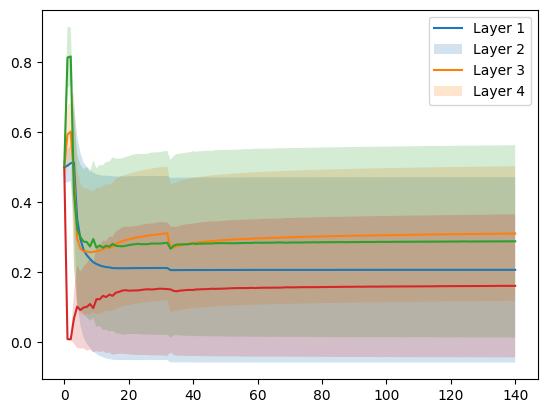

In [ ]:
legends = []
for name, activations in act_curve.items():
  plt.plot(range(141), activations['mean'])
  means = np.array(activations['mean'])
  stds = np.array(activations['std'])
  legends.append(name)
  plt.fill_between(range(141), means + stds, means - stds, alpha=0.2)
plt.legend(legends)
plt.show()